# Franck-Condon Factors calculation for YO molecules using the RKR inversion

In [2]:
"""
This is used to evaluate the frank-condo factors of YO 
The RKR inversion method is used, ref: The RKR Inversion Method by Kevin Lehmann
@author: mengjie
"""
import matplotlib.pyplot as plt 
import numpy as np
import math
import scipy
import pandas as pd
from scipy import interpolate
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigsh

# Franck-Condon Factors definition
FCFs quantify the relative intensities of vibronic (vibrational-electronic) spectral lines by calculating the square of the overlap integral between vibrational wavefunctions of two different electronic states
![My figure](FCF_figure.png)

# The code calculates the FCFs between the ground state of YO and two other excited states of interests
![YO_level_structure](YO_level.png)

In [3]:
"""
Define the vibrational and rotational constants for 
X_sig,A_Pi and B_Sig states for YO, quoted from paper
A.Bernard and R.Grabivina 1980
Units are cm^-1
"""
Equilibirum_constants={"X_Sig":{"omega_e":861.0,
                             "omega_ex":2.93,
                             "omega_ey":0.006, 
                             "B_e":0.3881,
                             "alpha_e":0.0018,
                             "D_e":0.318*10**(-6)},
                       "A_Pi":{"omega_e":846.9,
                             "omega_ex":3.346,
                             "omega_ey":0.014,
                             "B_e":0.38680,
                             "alpha_e":0.00201,
                             "D_e":0.344*10**(-6)},
                       "B_Sig":{"omega_e":804.5,
                             "omega_ex":3.97,
                             "omega_ey":0,
                             "B_e":0.37314,
                             "alpha_e":0.00249}}

h=6.6260755*10**(-34) # joule*sec
h_bar=h/(2*math.pi)
u=1.6605402*10**(-27) #kg
miu=88.90585*15.999/(15.999+88.90585)*u #reduced mass in amu
c=2.99792458*10**8 #meter per sec
As=1*10**(-10) #angstrom

def G(v,elec_state): #continuous function G(v) fitting the vibrational energies in unit m^-1
    G_v=Equilibirum_constants[elec_state]["omega_e"]*(v+1/2)\
        -Equilibirum_constants[elec_state]["omega_ex"]*(v+1/2)**2\
            +Equilibirum_constants[elec_state]["omega_ey"]*(v+1/2)**3
    return G_v*100

def B(v,elec_state):#continuous function B(v) fitting for the rotational constant in unit m^-1
    B_v=Equilibirum_constants[elec_state]["B_e"]\
        -Equilibirum_constants[elec_state]["alpha_e"]*(v+1/2)
    return B_v*100

def constant_C():
    C=math.sqrt(h/(8*math.pi**2*c*miu))
    
    return C/As # return C in units of Angstrom

def f(v,elec_state):
    x=[-0.84431321698,-0.26935495247,0.44763137226,0.93270346386]
    H=[0.28631753784,0.62898854988,0.88729638641,1.02582465061]
    return constant_C()*(v+0.5)/2\
        *sum(H[i]*math.sqrt(1-x[i])\
             *1/math.sqrt(G(v, elec_state)-G((v-0.5)/2+(v+0.5)/2*x[i],elec_state))\
                 for i in range(0,4))

def g(v,elec_state):
    x=[-0.84431321698,-0.26935495247,0.44763137226,0.93270346386]
    H=[0.28631753784,0.62898854988,0.88729638641,1.02582465061]
    return 1/constant_C()*(v+0.5)/2\
        *sum(H[i]*math.sqrt(1-x[i])\
             *B((v-0.5)/2+(v+0.5)/2*x[i],elec_state)/math.sqrt(G(v, elec_state)-G((v-0.5)/2+(v+0.5)/2*x[i],elec_state))\
                 for i in range(0,4))
            
def r_inner(v,elec_state):#in unit of Angstrom
    return math.sqrt(f(v,elec_state)**2+f(v,elec_state)/g(v,elec_state))-f(v,elec_state)
    
def r_outer(v,elec_state):#in unit of Angstrom
    return math.sqrt(f(v,elec_state)**2+f(v,elec_state)/g(v,elec_state))+f(v,elec_state)

## Calculate the potential and wavefunctions for $X\Sigma$ state

Text(0.5, 1.0, 'The RKR curve for the YO ground state')

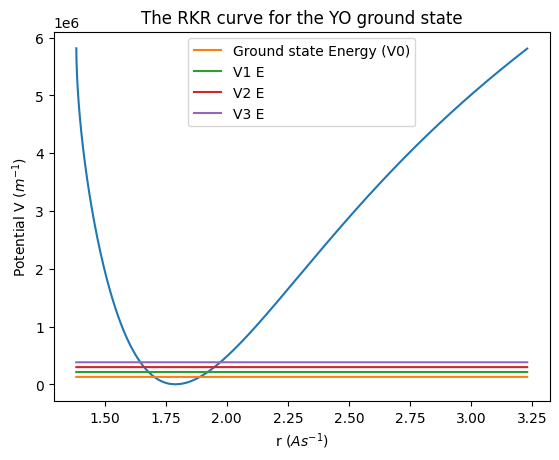

In [48]:
electronic_state="X_Sig" 
N=1800
v=[0]*N
r=[0]*N
V=[0]*N
for i in range(0,int(N/2)):
    v[i]=0.1*(int(N/2)-5-i) 
    r[i]=r_inner(v[i], electronic_state) 
    V[i]=G(v[i],electronic_state)

v[int(N/2)]=-0.5
r[int(N/2)]=constant_C()/math.sqrt(B(-0.5,electronic_state))
V[int(N/2)]=G(-0.5,electronic_state)
    
for i in range(int(N/2)+1,int(N)):
    v[i]=0.1*(i-(int(N/2+5)))
    r[i]=r_outer(v[i],electronic_state)
    V[i]=G(v[i],electronic_state)

fig1,ax1=plt.subplots(1)
ax1.plot(r,V)
ax1.plot(r,len(r)*[G(1,"X_Sig")], label = "Ground state Energy (V0)")
ax1.plot(r,len(r)*[G(2,"X_Sig")], label = "V1 E")
ax1.plot(r,len(r)*[G(3,"X_Sig")], label = "V2 E")
ax1.plot(r,len(r)*[G(4,"X_Sig")], label = "V3 E")
ax1.legend()
ax1.set_xlabel("r $(As^{-1})$")
ax1.set_ylabel("Potential V $(m^{-1})$")
ax1.set_title("The RKR curve for the YO ground state")

## Interpolate the potential to get a function that can be evaluated at any location

In [49]:
func_V_of_r=interpolate.interp1d(r,V) # this is the potential function V(r)

#plt.plot(r_new,func_V_of_r(r_new))
func_r_of_V=interpolate.interp1d(V,r) #r(V)
def f_bound(x):
    return func_V_of_r(x)-20*G(0,electronic_state)
root = fsolve(f_bound,[1.5,2.2])

def shrodinger_solver(N_dim):
    """
    This function solves -h_bar^2/(2m)*d/dx^2 psi(x)+V(x)psi(x)==E Psi(x)
    Parameters
    ----------
    N_dim : the dimension of the square discretization matrix, N*N, 

    Returns
    -------
    An k dimension array of smallest eigenvalues
    An k by N_dim dimension of Matrix, [:,i] correspond to the ith eigenvalue

    """
    r_inner_bound = 1.5
    r_outer_bound = 2.4
    x=np.linspace(r_inner_bound,r_outer_bound,N_dim)
    dx=(r_outer_bound-r_inner_bound)/N_dim
    "D2 is the Laplace operator expressed in matrix form"
    D2 = scipy.sparse.diags([1, -2, 1], [-1, 0, 1], shape=(x.size, x.size), dtype=np.float64) / ((dx*As)**2)
    H=-h_bar**2/(2*miu)/(h*c)*D2+np.diag(func_V_of_r(x))

    return eigsh(H,which='SM')

N_dim=1500
eigenvalues_X_Sig, eigenvectors_X_Sig = shrodinger_solver(N_dim)
def psi_X_Sig(v):
    return eigenvectors_X_Sig[:,v]

def psi_norm_X_Sig(v):
    psi_norm=psi_X_Sig(v)
    det=max(np.abs(psi_norm))
    if det<0:
        psi_norm=-1*psi_norm 
    return psi_norm

## Confirm that the eigenvalues calculated using the connstructed potential curve matches the eigen-energies extracted from the spectroscopy constants

In [50]:
print("Electronic state: ", electronic_state)
for i in range(0, 6):
    spectroscopy_value = G(i, electronic_state)
    reconstructed_value = eigenvalues_X_Sig[i]

    relative_error = abs(reconstructed_value - spectroscopy_value) / abs(spectroscopy_value)

    if relative_error > 0.05:
        print(
            f"v = {i}: more than 1% discrepancy. "
            f"Spectroscopy = {spectroscopy_value:.6f}, "
            f"Reconstructed = {reconstructed_value:.6f}, "
            f"Relative error = {relative_error:.2%}"
        )

    else:
        print(f"The discrepency between reconstructed {i} th vibrational energy and spectroscopy energy is within 5%")

Electronic state:  X_Sig
The discrepency between reconstructed 0 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 1 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 2 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 3 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 4 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 5 th vibrational energy and spectroscopy energy is within 5%


## Calculate the potential and wavefunctions for $B\Sigma$ state

Electronic state:  B_Sig
The discrepency between reconstructed 0 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 1 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 2 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 3 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 4 th vibrational energy and spectroscopy energy is within 5%
The discrepency between reconstructed 5 th vibrational energy and spectroscopy energy is within 5%


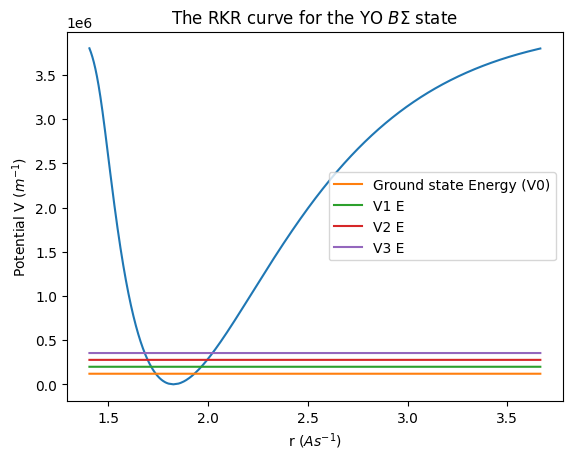

In [51]:
electronic_state="B_Sig"
N=1500
v=[0]*N
r=[0]*N
V=[0]*N
for i in range(0,int(N/2)):
    v[i]=0.1*(int(N/2)-5-i) 
    r[i]=r_inner(v[i], electronic_state) 
    V[i]=G(v[i],electronic_state)

v[int(N/2)]=-0.5
r[int(N/2)]=constant_C()/math.sqrt(B(-0.5,electronic_state))
V[int(N/2)]=G(-0.5,electronic_state)
   
for i in range(int(N/2)+1,int(N)):
    v[i]=0.1*(i-(int(N/2)+5))
    r[i]=r_outer(v[i],electronic_state)
    V[i]=G(v[i],electronic_state)

ax1.plot(r,V,label="B Sig")

"""
I need to interpolate the potential to get a function that can be evaluated at any location
"""
func_V_of_r=interpolate.interp1d(r,V) # this is the potential function V(r)
func_r_of_V=interpolate.interp1d(V,r) #r(V)


N_dim=1500
eigenvalues_B_Sig, eigenvectors_B_Sig = shrodinger_solver(N_dim)
fig1,ax1=plt.subplots(1)
ax1.plot(r,V)
ax1.plot(r,len(r)*[G(1,"B_Sig")], label = "Ground state Energy (V0)")
ax1.plot(r,len(r)*[G(2,"B_Sig")], label = "V1 E")
ax1.plot(r,len(r)*[G(3,"B_Sig")], label = "V2 E")
ax1.plot(r,len(r)*[G(4,"B_Sig")], label = "V3 E")
ax1.legend()
ax1.set_xlabel("r $(As^{-1})$")
ax1.set_ylabel("Potential V $(m^{-1})$")
ax1.set_title(r"The RKR curve for the YO $B\Sigma$ state")

def psi_B_Sig(v):
    return eigenvectors_B_Sig[:,v]

def psi_norm_B_Sig(v):
    psi_norm=psi_B_Sig(v)
    det=psi_norm[len(psi_norm)-100]
    if det<0:
        psi_norm=-1*psi_norm
    return psi_norm

print("Electronic state: ", electronic_state)
for i in range(0, 6):
    spectroscopy_value = G(i, electronic_state)
    reconstructed_value = eigenvalues_B_Sig[i]

    relative_error = abs(reconstructed_value - spectroscopy_value) / abs(spectroscopy_value)

    if relative_error > 0.05:
        print(
            f"v = {i}: more than 1% discrepancy. "
            f"Spectroscopy = {spectroscopy_value:.6f}, "
            f"Reconstructed = {reconstructed_value:.6f}, "
            f"Relative error = {relative_error:.2%}"
        )

    else:
        print(f"The discrepency between reconstructed {i} th vibrational energy and spectroscopy energy is within 5%")

# Calculate the potential and wavefunctions for $A\Pi$ state

Franck-condon factors for APi V=0 XSigma V=0 0.9981555440699341
Franck-condon factors for APi V=0 XSigma V=1 0.0018277435044522046
0.07908653742742697
3


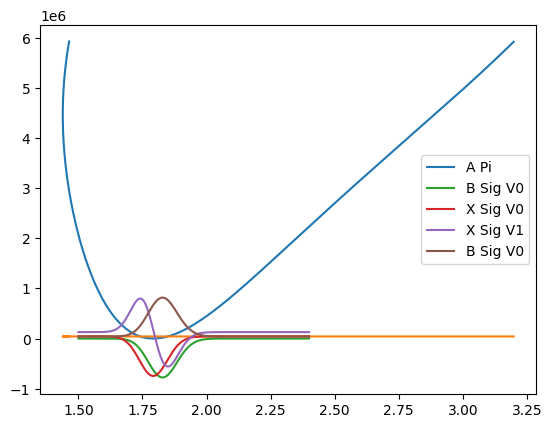

In [54]:
"""
Calculate the potential and wavefunctions for A_Pi state
"""
electronic_state="A_Pi"
N=1800
v=[0]*N
r=[0]*N
V=[0]*N
for i in range(0,int(N/2)):
    v[i]=0.1*(int(N/2)-5-i) 
    r[i]=r_inner(v[i], electronic_state) 
    V[i]=G(v[i],electronic_state)

v[int(N/2)]=-0.5
r[int(N/2)]=constant_C()/math.sqrt(B(-0.5,electronic_state))
V[int(N/2)]=G(-0.5,electronic_state)
    
for i in range(int(N/2)+1,int(N)):
    v[i]=0.1*(i-(int(N/2+5)))
    r[i]=r_outer(v[i],electronic_state)
    V[i]=G(v[i],electronic_state)
fig3,ax3=plt.subplots(1)
ax3.plot(r,V,label="A Pi")


plt.plot(r,len(r)*[G(0,"A_Pi")])

"""
I need to interpolate the potential to get a function that can be evaluated at any location
"""
func_V_of_r=interpolate.interp1d(r,V) # this is the potential function V(r)

func_r_of_V=interpolate.interp1d(V,r) #r(V)

N_dim=1500
eigenvalues_A_Pi, eigenvectors_A_Pi = shrodinger_solver(N_dim)

# I fix the inner and outer bounds for the 
# convinence of calculating the overlap beween the wavefunctions
# I need to normalize the eigenvectors
def psi_A_Pi(v):
    return eigenvectors_A_Pi[:,v]


def psi_norm_A_Pi(v):
    psi_norm=psi_A_Pi(v)
    det=psi_norm[len(psi_norm)-100]
    if det<0:
        psi_norm=-1*psi_norm
    return psi_norm

AP_XS_zerozero=sum(psi_norm_A_Pi(0)*psi_norm_X_Sig(0))**2
AP_XS_zeroone=sum(psi_norm_A_Pi(0)*psi_norm_X_Sig(1))**2

print("Franck-condon factors for APi V=0 XSigma V=0",AP_XS_zerozero )
print("Franck-condon factors for APi V=0 XSigma V=1",AP_XS_zeroone )

r_inner_bound = 1.5
r_outer_bound = 2.4
x=np.linspace(r_inner_bound,r_outer_bound,N_dim)
plt.plot(x,10**7*psi_B_Sig(0),label="B Sig V0")
ax3.plot(x,10**7*psi_norm_X_Sig(0)+eigenvalues_X_Sig[0],label="X Sig V0")
ax3.plot(x,10**7*psi_norm_X_Sig(1)+eigenvalues_X_Sig[1],label="X Sig V1")
ax3.plot(x,10**7*psi_norm_B_Sig(0)+eigenvalues_B_Sig[0],label="B Sig V0")

#ax1.plot(x,10**7*psi_norm_X_Sig(2)+eigenvalues_X_Sig[2],label="X Sig V2")
ax3.legend()
print(max(np.abs(psi_X_Sig(0))))
print(max(np.abs([0,-1,-3,1])))

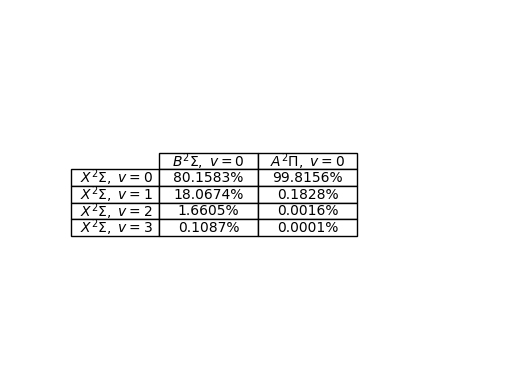

In [65]:
df = pd.DataFrame(
    {
        r'$B^2\Sigma,\ v=0$': [
            f"{BS_XS_zerozero:.4%}",
            f"{BS_XS_zeroone:.4%}",
            f"{BS_XS_zerotwo:.4%}",
            f"{BS_XS_zerothree:.4%}"
        ],

        r'$A^2\Pi,\ v=0$': [
            f"{AP_XS_zerozero:.4%}",
            f"{AP_XS_zeroone:.4%}",
            f"{AP_XS_zerotwo:.4%}",
            f"{AP_XS_zerothree:.4%}"
        ],
    },
    index=[
        r'$X^2\Sigma,\ v=0$',
        r'$X^2\Sigma,\ v=1$',
        r'$X^2\Sigma,\ v=2$',
        r'$X^2\Sigma,\ v=3$'
    ]
)

fig2, ax2 = plt.subplots()
ax2.axis('off')

table = pd.plotting.table(
    ax2,
    df,
    loc='center',
    cellLoc='center',
    colWidths=[0.2, 0.2])

# Conclusion

The calculated FCF suggest that if we want to repump $X\Sigma$ V=1 to $B\Sigma$ V=0 in order to decouple the $X\Sigma$ V=1 from the $A\Pi$ V=0 state so that YO can have faster scattering rate during laser slowing, we need either buy an addtional V=3 repumper or slow YO molecules within the shortened lifetime due to increased chance of decaying into V=3 state.